# DARTS

## Introducción

Biblioteca específica de Python para series de tiempo. Su objetivo es simplificar todo el proceso de modelado, pronóstico y análisis de datos temporales.


Proporciona una interfaz para usar diferentes tipos de modelos:

- Modelos estadísticos clásicos (ARIMA, exponential smoothing)

- Modelos de machine learning (Random Forest, LightGBM)

- Modelos de deep learning (LSTM, Transformer, N-BEATS)

## Librerias

In [ ]:
! pip install darts

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.9/62.9 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 1.7 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of numba to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 744.5/744.5 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.7/204.7 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 8.6 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-

In [ ]:
import darts

In [ ]:
# Se cargan las librerías
from pandas import DataFrame
from pandas import concat
import random
from scipy import stats
import numpy as np
import pandas as pd
from math import sqrt
from numpy import concatenate
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from darts.metrics import mape, rmse, mae
from pandas import DataFrame
from pandas import concat
import seaborn as sn
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import gc
#from darts.ad import QuantileDetector
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [ ]:
pip install pytorch-lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 38.5 MB/s eta 0:00:00


In [ ]:
from darts import TimeSeries
from darts.models import (NaiveSeasonal,NaiveDrift,RNNModel,Prophet,ExponentialSmoothing,ARIMA,AutoARIMA,TCNModel,TransformerModel,Theta,FFT)

## Paso 1: Preparar los datos

Preparar los datos es un paso importante en series de tiempo porque los modelos necesitan entender la estructura temporal de los datos. Un índice datetime correcto permite que el modelo identifique patrones estacionales y tendencias. Los datos mal preparados generan modelos que no detectan patrones reales, mientras que datos limpios permiten predicciones confiables que pueden identificar correctamente picos de cortes de luz y tendencias temporales.

**Variable objetivo:** Búsquedas de Google Trends (proxy de cortes de luz)
**Variables exógenas**: Temp (temperatura), Hum (humedad)
**Índice temporal:** Semana (datos semanales)

In [ ]:
df = pd.read_csv(
    "completo.csv",
    parse_dates=["Semana"],
    index_col="Semana"
)

for col in ["Temp", "Hum"]:
    if df[col].dtype == object:
        df[col] = df[col].str.replace(",", ".", regex=False).astype(float)

df = df.asfreq("W-SUN")

df = df.sort_index()

print("Período:", df.index.min().date(), "→", df.index.max().date())
print("Observaciones:", len(df))
print("Columnas:", list(df.columns))

df.head()

Período: 2020-12-06 → 2025-12-07
Observaciones: 262
Columnas: ['Cortes', 'Temp', 'Hum']


,Cortes,Temp,Hum
Semana,,,
2020-12-06,17,20.735714,62.532857
2020-12-13,23,24.490000,49.370000
2020-12-20,22,23.690000,51.560000
2020-12-27,37,27.928571,48.910000
2021-01-03,27,27.341429,39.745714


In [ ]:
df['Temp'] = df['Temp'].astype(str).str.replace(',', '.').astype(float)
df['Hum'] = df['Hum'].astype(str).str.replace(',', '.').astype(float)

print(df.head())

            Cortes       Temp        Hum
Semana                                  
2020-12-06      17  20.735714  62.532857
2020-12-13      23  24.490000  49.370000
2020-12-20      22  23.690000  51.560000
2020-12-27      37  27.928571  48.910000
2021-01-03      27  27.341429  39.745714


In [ ]:
from darts import TimeSeries

TEST_FRAC = 0.20
N = len(df)
N_TRAIN = int(N * (1 - TEST_FRAC))

splits = {}

for col in ["Cortes", "Temp", "Hum"]:

    ts = TimeSeries.from_series(df[col])

    train = ts[:N_TRAIN]
    test  = ts[N_TRAIN:]

    splits[col] = {
        "train": train,
        "test": test
    }

    print(f"{col}: Train={len(train)} | Test={len(test)}")

Cortes: Train=209 | Test=53
Temp: Train=209 | Test=53
Hum: Train=209 | Test=53


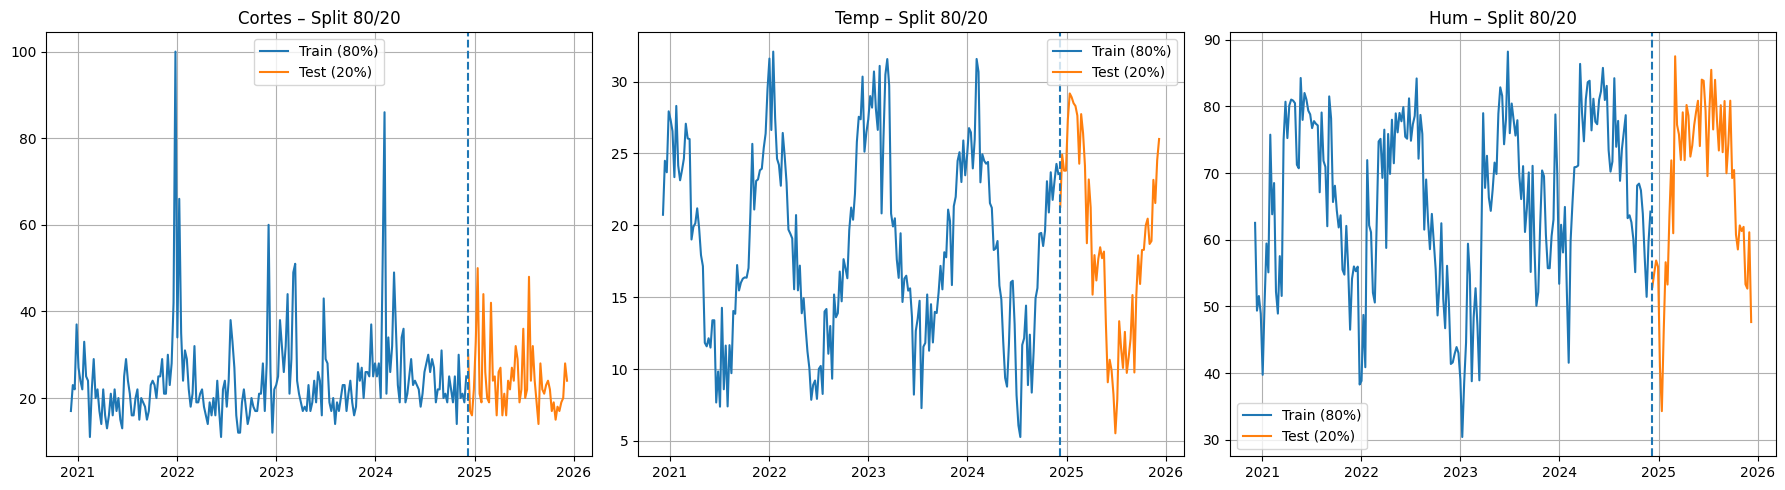

In [ ]:
import matplotlib.pyplot as plt

# Fecha exacta del corte
split_date = df.index[N_TRAIN]

fig, axes = plt.subplots(1, 3, figsize=(18,5), sharex=False)

for i, col in enumerate(["Cortes", "Temp", "Hum"]):

    train = df[col].iloc[:N_TRAIN]
    test  = df[col].iloc[N_TRAIN:]

    axes[i].plot(train.index, train.values, label="Train (80%)")
    axes[i].plot(test.index, test.values, label="Test (20%)")

    # Línea roja divisoria
    axes[i].axvline(split_date, linestyle="--")

    axes[i].set_title(f"{col} – Split 80/20")
    axes[i].grid(True)
    axes[i].legend()

plt.tight_layout()
plt.show()

## Modelo Exponential Smoothing


El modelo **Exponential Smoothing**, pondera más las observaciones recientes y menos las lejanas para capturar tendencias. Sirve como punto de referencia o *benchmark*, cualquier modelo más complejo debe superar este modelo para justificar su uso.

Evaluamos el desempeño utiliando 3 métricas:

- **MAPE** : Error porcentual promedio ("me equivoco x% en promedio").

- **MAE**: Error absoluto robusto a outliers.

- **RMSE**: Root Mean Square Error (pensaliza errores grandes, nos ayuda a ver si fallamos mucho cuando la serie se dispara).


=== Cortes ===


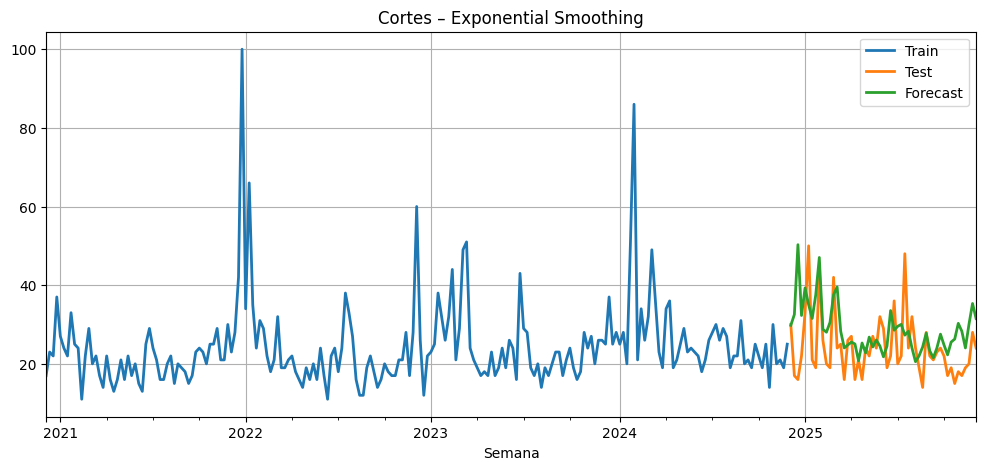


=== Temp ===


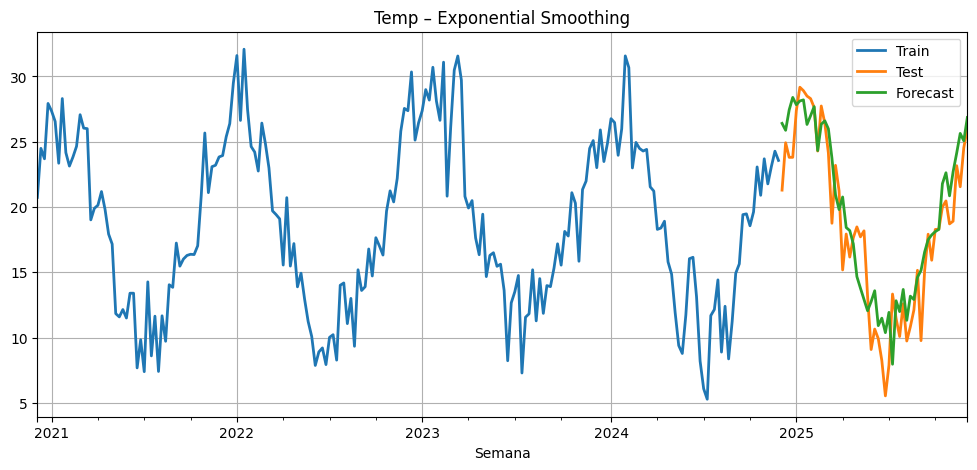


=== Hum ===


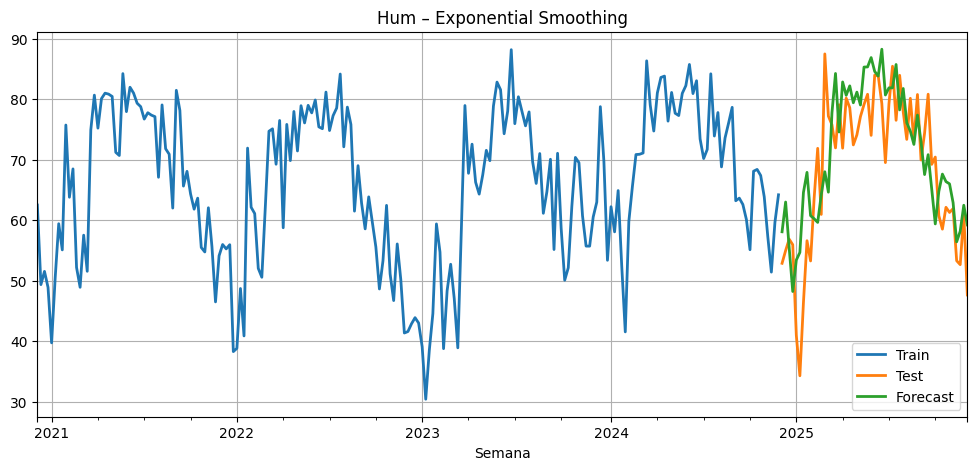

,RMSE,MAE
Cortes,9.574683,7.395756
Temp,2.747409,2.175471
Hum,8.243775,6.679558


In [ ]:
from darts.models import ExponentialSmoothing
from darts.metrics import rmse, mae
import matplotlib.pyplot as plt
import pandas as pd

results_exp = {}

for name in ["Cortes", "Temp", "Hum"]:

    print(f"\n=== {name} ===")

    train = splits[name]["train"]
    test  = splits[name]["test"]

    model = ExponentialSmoothing()
    model.fit(train)

    forecast = model.predict(len(test))

    rmse_val = rmse(test, forecast)
    mae_val  = mae(test, forecast)

    results_exp[name] = {
        "RMSE": float(rmse_val),
        "MAE": float(mae_val)
    }

    # Gráfico
    plt.figure(figsize=(12,5))
    train.plot(label="Train")
    test.plot(label="Test")
    forecast.plot(label="Forecast")
    plt.title(f"{name} – Exponential Smoothing")
    plt.legend()
    plt.grid(True)
    plt.show()

pd.DataFrame(results_exp).T

In [ ]:
from darts.models import ExponentialSmoothing

forecasts_exp = {}

for serie in ["Cortes", "Temp", "Hum"]:

    train = splits[serie]["train"]
    test  = splits[serie]["test"]

    model = ExponentialSmoothing()
    model.fit(train)

    forecast = model.predict(len(test))

    forecasts_exp[serie] = forecast

## Modelo FFT (Fast Fourier Transform)

Tras evaluar modelos estadísticos clásicos (Exponential Smoothing, ARIMA) y redes neuronales profundas (LSTM), exploramos un enfoque radicalmente diferente basado en análisis espectral: la **Transformada Rápida de Fourier (FFT)**. A diferencia de los modelos anteriores que trabajan en el dominio temporal (prediciendo valores futuros basándose en valores pasados secuenciales), FFT opera en el dominio de frecuencias, descomponiendo la serie temporal en una suma de ondas sinusoidales de diferentes frecuencias que, al combinarse, reconstruyen el patrón observado. Este enfoque es particularmente poderoso cuando la serie exhibe periodicidades claras y regulares: si las búsquedas de cortes de luz siguen ciclos predecibles (estacionalidad anual relacionada con clima, patrones mensuales de consumo eléctrico, o fluctuaciones semanales de actividad), FFT identifica estas frecuencias dominantes y las utiliza para proyectar el comportamiento futuro.

El algoritmo FFT transforma la serie de tiempo desde su representación original (valores de búsquedas semana a semana) a una representación espectral que muestra la intensidad de cada frecuencia presente en los datos.  El parámetro *nr_freqs_to_keep=10* retiene solo las 10 frecuencias más importantes (aquellas con mayor amplitud), filtrando ruido de alta frecuencia que no aporta poder predictivo y podría causar sobreajuste. Esta selección automática de componentes relevantes es análoga a reducción de dimensionalidad: en lugar de modelar cada fluctuación aleatoria, FFT captura solo los ciclos estructurales que genuinamente explican la dinámica de la serie.

Adicionalmente, incorporamos *modelado de tendencia polinomial* (trend='poly', degree=2) que captura movimientos de largo plazo no cíclicos antes de aplicar la descomposición de frecuencias. Esto es crucial porque FFT asume que la serie es estacionaria (sin tendencia global). El polinomio de grado 2 permite modelar tendencias curvadas (parabólicas): si las búsquedas han estado aumentando aceleradamente, el componente polinomial lo captura, mientras que FFT modela las oscilaciones alrededor de esa tendencia.

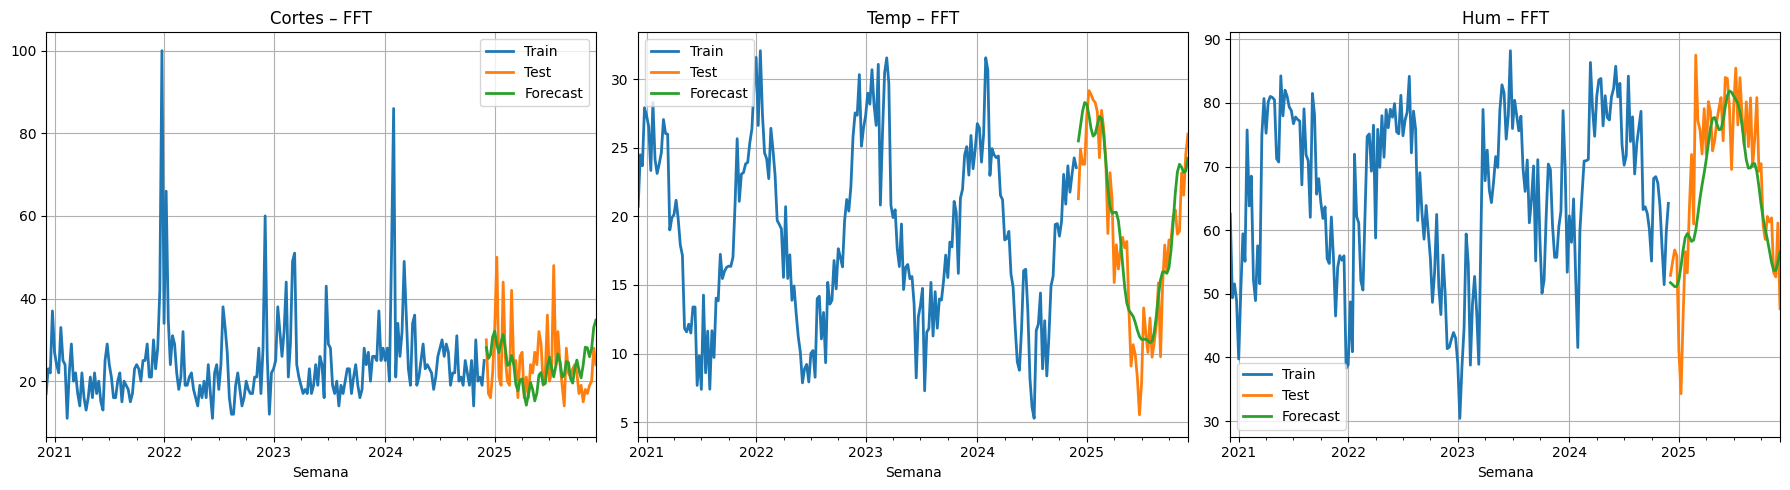

,RMSE,MAE
Cortes,8.111080,6.168456
Temp,2.642566,2.152374
Hum,7.760180,5.788553


In [ ]:
from darts.models import FFT
from darts.metrics import rmse, mae
import matplotlib.pyplot as plt
import pandas as pd

results_fft = {}

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for i, name in enumerate(["Cortes", "Temp", "Hum"]):

    train = splits[name]["train"]
    test  = splits[name]["test"]

    # Modelo FFT
    model = FFT()
    model.fit(train)

    forecast = model.predict(len(test))

    # Métricas
    rmse_val = rmse(test, forecast)
    mae_val  = mae(test, forecast)

    results_fft[name] = {
        "RMSE": float(rmse_val),
        "MAE": float(mae_val)
    }

    # Gráfico
    train.plot(ax=axes[i], label="Train")
    test.plot(ax=axes[i], label="Test")
    forecast.plot(ax=axes[i], label="Forecast")

    axes[i].set_title(f"{name} – FFT")
    axes[i].grid(True)
    axes[i].legend()

plt.tight_layout()
plt.show()

# Tabla resumen
pd.DataFrame(results_fft).T

In [ ]:
from darts.models import FFT

forecasts_fft = {}

for serie in ["Cortes", "Temp", "Hum"]:

    train = splits[serie]["train"]
    test  = splits[serie]["test"]

    model = FFT()
    model.fit(train)

    forecast = model.predict(len(test))

    forecasts_fft[serie] = forecast

## Modelo Transformers

Habiendo explorado LSTM que procesa secuencias temporales de forma recurrente (paso a paso, manteniendo memoria mediante compuertas), avanzamos hacia la arquitectura más revolucionaria en deep learning de la última década: **Transformers**. Originalmente desarrollados para procesamiento de lenguaje natural (GPT, BERT), los Transformers han demostrado capacidad excepcional en series temporales al introducir el *mecanismo de atención*, que permite al modelo identificar qué partes del pasado son más relevantes para predecir el futuro sin procesar secuencialmente cada timestep. A diferencia de LSTM que "lee" la serie de izquierda a derecha actualizando su estado interno gradualmente, Transformer observa simultáneamente todos los puntos temporales y aprende pesos de atención que cuantifican la importancia relativa de cada semana histórica para la predicción actual, capturando dependencias tanto locales (últimas 2-3 semanas) como globales (patrones de hace 30+ semanas) de forma más eficiente.


Los hiperparámetros balancean expresividad y eficiencia computacional: *d_model=64* define la dimensionalidad de las representaciones internas (menor que modelos de lenguaje natural que usan 512-1024, ajustado a nuestro dataset más pequeño); *dim_feedforward=128* controla la capacidad de las capas densas dentro de cada bloque Transformer; *dropout=0.1* regulariza para prevenir sobreajuste; y *learning rate=1e-3* (menor que LSTM's 1e-2) reconoce que Transformers requieren optimización más cautelosa. Crítico destacar que Transformer *no tiene sesgo inductivo temporal* como LSTM (que asume que el pasado reciente es más importante): aprende completamente desde datos qué patrones temporales importan, lo cual es poderoso si hay suficientes datos pero arriesgado con datasets pequeños (~150 observaciones).

### Transformers univariado

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

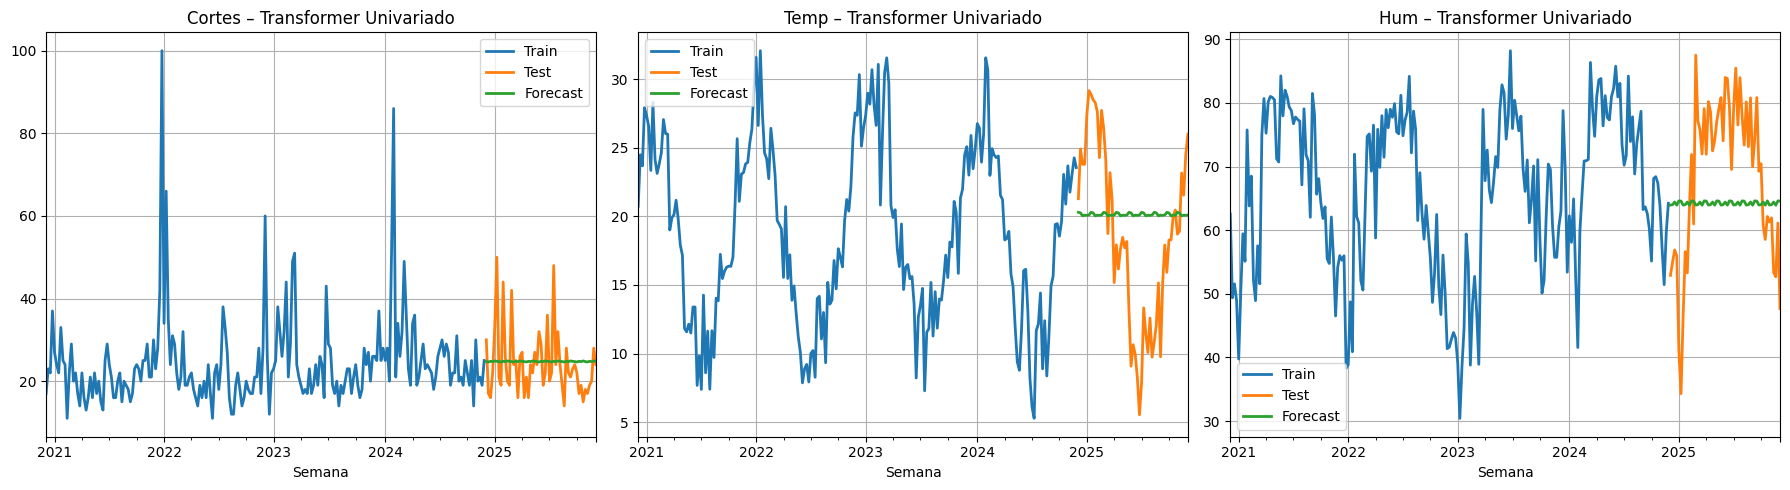

,RMSE,MAE
Cortes,7.910586,5.857847
Temp,6.632150,5.579777
Hum,13.140554,11.562073


In [ ]:
from darts.models import TransformerModel
from darts.metrics import rmse, mae
import matplotlib.pyplot as plt
import pandas as pd

results_trans_uni = {}

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for i, name in enumerate(["Cortes", "Temp", "Hum"]):

    train = splits[name]["train"]
    test  = splits[name]["test"]

    model = TransformerModel(
        input_chunk_length=12,
        output_chunk_length=6,
        n_epochs=100,
        random_state=42,
        force_reset=True,
        model_name=f"transf_uni_{name}"
    )

    model.fit(train, verbose=False)

    forecast = model.predict(len(test))

    rmse_val = rmse(test, forecast)
    mae_val  = mae(test, forecast)

    results_trans_uni[name] = {
        "RMSE": float(rmse_val),
        "MAE": float(mae_val)
    }

    train.plot(ax=axes[i], label="Train")
    test.plot(ax=axes[i], label="Test")
    forecast.plot(ax=axes[i], label="Forecast")

    axes[i].set_title(f"{name} – Transformer Univariado")
    axes[i].grid(True)
    axes[i].legend()

plt.tight_layout()
plt.show()

pd.DataFrame(results_trans_uni).T

In [ ]:
from darts.models import TransformerModel

forecasts_trans_uni = {}

for serie in ["Cortes", "Temp", "Hum"]:

    train = splits[serie]["train"]
    test  = splits[serie]["test"]

    model = TransformerModel(
        input_chunk_length=12,
        output_chunk_length=6,
        n_epochs=100,
        random_state=42,
        force_reset=True
    )

    model.fit(train, verbose=False)

    forecast = model.predict(len(test))

    forecasts_trans_uni[serie] = forecast

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

### Transformers multivariados

In [ ]:
from darts import TimeSeries

# Crear serie multivariada
multi_series = TimeSeries.from_dataframe(df[["Cortes", "Temp", "Hum"]])

train_multi = multi_series[:N_TRAIN]
test_multi  = multi_series[N_TRAIN:]

model_multi = TransformerModel(
    input_chunk_length=12,
    output_chunk_length=6,
    n_epochs=100,
    random_state=42,
    force_reset=True,
    model_name="transf_multi"
)

model_multi.fit(train_multi, verbose=False)

forecast_multi = model_multi.predict(len(test_multi))

# Evaluar cada variable por separado
results_trans_multi = {}

for i, name in enumerate(["Cortes", "Temp", "Hum"]):

    rmse_val = rmse(test_multi[name], forecast_multi[name])
    mae_val  = mae(test_multi[name], forecast_multi[name])

    results_trans_multi[name] = {
        "RMSE": float(rmse_val),
        "MAE": float(mae_val)
    }

pd.DataFrame(results_trans_multi).T

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

,RMSE,MAE
Cortes,8.070095,6.217362
Temp,6.403513,5.351350
Hum,13.448256,11.655323


In [ ]:
from darts import TimeSeries

multi_series = TimeSeries.from_dataframe(df[["Cortes", "Temp", "Hum"]])

train_multi = multi_series[:N_TRAIN]
test_multi  = multi_series[N_TRAIN:]

model_multi = TransformerModel(
    input_chunk_length=12,
    output_chunk_length=6,
    n_epochs=100,
    random_state=42,
    force_reset=True
)

model_multi.fit(train_multi, verbose=False)

forecast_multi = model_multi.predict(len(test_multi))

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

## Comparación modelos Darts

In [ ]:
import pandas as pd

def build_metrics_df(model_name, metrics_dict):
    rows = []
    for serie in metrics_dict:
        rows.append({
            "model": model_name,
            "serie": serie,
            "rmse": metrics_dict[serie]["RMSE"],
            "mae": metrics_dict[serie]["MAE"]
        })
    return pd.DataFrame(rows)

df_exp  = build_metrics_df("exp_smoothing", results_exp)
df_fft  = build_metrics_df("fft", results_fft)
df_uni  = build_metrics_df("transformer_uni", results_trans_uni)
df_multi = build_metrics_df("transformer_multi", results_trans_multi)

comparison_darts = pd.concat([df_exp, df_fft, df_uni, df_multi])

comparison_darts

,model,serie,rmse,mae
0,exp_smoothing,Cortes,9.574683,7.395756
1,exp_smoothing,Temp,2.747409,2.175471
2,exp_smoothing,Hum,8.243775,6.679558
0,fft,Cortes,8.111080,6.168456
1,fft,Temp,2.642566,2.152374
2,fft,Hum,7.760180,5.788553
0,transformer_uni,Cortes,7.910586,5.857847
1,transformer_uni,Temp,6.632150,5.579777
2,transformer_uni,Hum,13.140554,11.562073
0,transformer_multi,Cortes,8.070095,6.217362


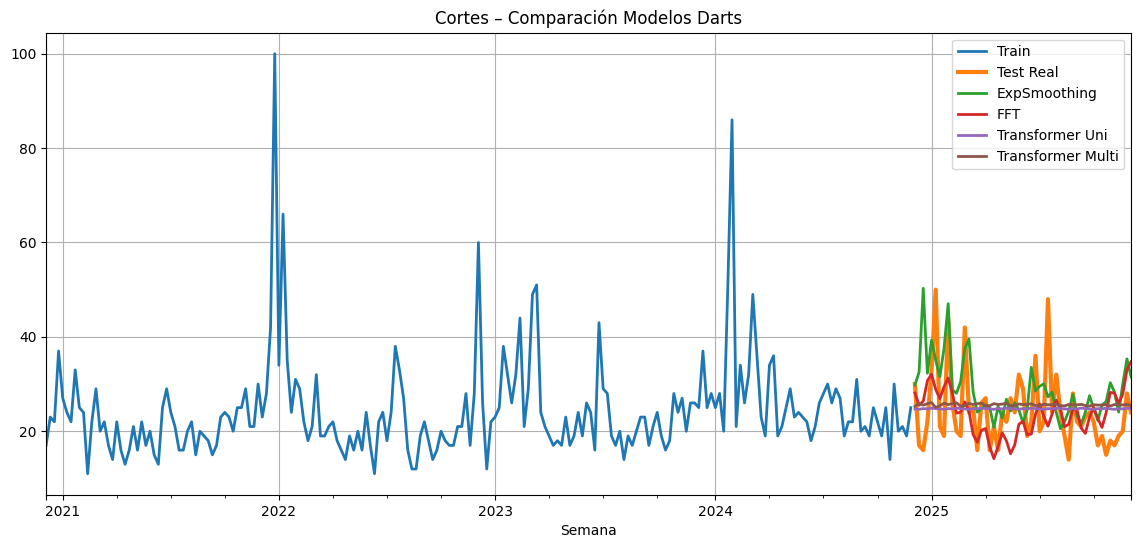

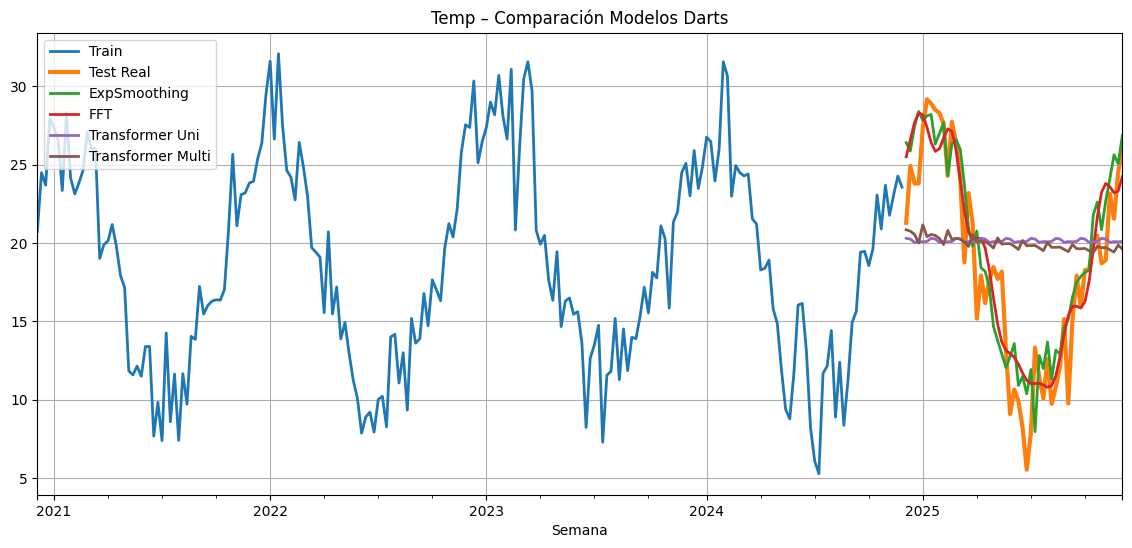

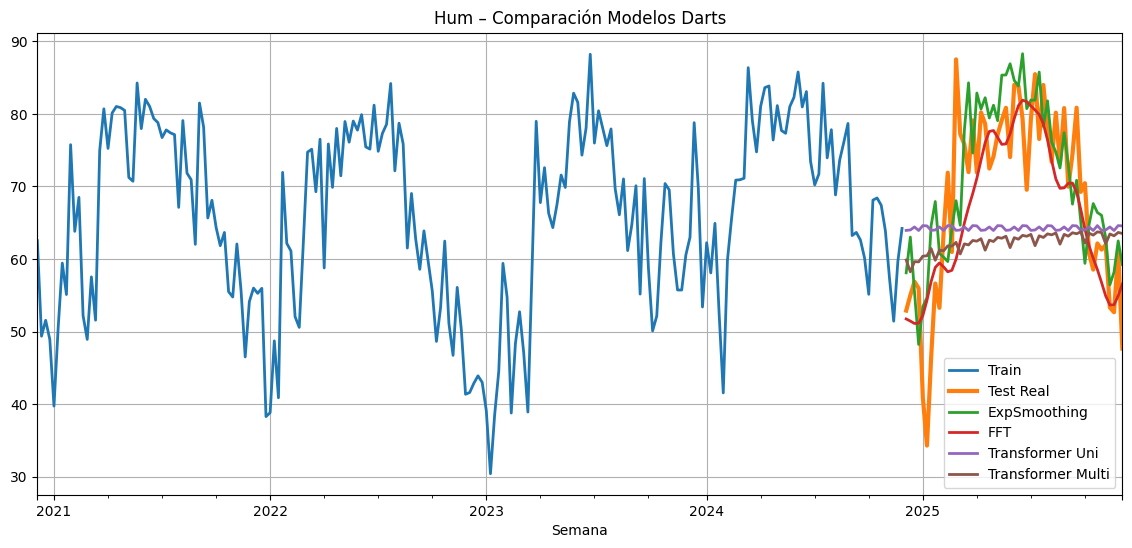

In [ ]:
import matplotlib.pyplot as plt

for serie in ["Cortes", "Temp", "Hum"]:

    train = splits[serie]["train"]
    test  = splits[serie]["test"]

    plt.figure(figsize=(14,6))

    train.plot(label="Train", linewidth=2)
    test.plot(label="Test Real", linewidth=3)

    forecasts_exp[serie].plot(label="ExpSmoothing")
    forecasts_fft[serie].plot(label="FFT")
    forecasts_trans_uni[serie].plot(label="Transformer Uni")

    forecast_multi[serie].plot(label="Transformer Multi")

    plt.title(f"{serie} – Comparación Modelos Darts")
    plt.legend()
    plt.grid(True)
    plt.show()

## Guardado de datos para comparación final

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = "/content/drive/MyDrive/SDT/Resultados"

Mounted at /content/drive


In [ ]:
import pandas as pd
from darts.metrics import rmse, mae

def export_darts_model(model_name, forecasts_dict):

    all_preds = []
    all_metrics = []

    for serie in ["Cortes", "Temp", "Hum"]:

        test = splits[serie]["test"]
        forecast = forecasts_dict[serie]

        # ---- Predicciones ----
        df_pred = pd.DataFrame({
            "model": model_name,
            "serie": serie,
            "date": test.time_index,
            "y_true": test.values().flatten(),
            "y_pred": forecast.values().flatten()
        })

        all_preds.append(df_pred)

        # ---- Métricas recalculadas ----
        rmse_val = float(rmse(test, forecast))
        mae_val  = float(mae(test, forecast))

        all_metrics.append({
            "model": model_name,
            "serie": serie,
            "rmse": rmse_val,
            "mae": mae_val
        })

    df_predictions = pd.concat(all_preds)
    df_metrics = pd.DataFrame(all_metrics)

    df_predictions.to_csv(f"{BASE_PATH}/predictions_{model_name}.csv", index=False)
    df_metrics.to_csv(f"{BASE_PATH}/metrics_{model_name}.csv", index=False)

    print(f"✔ {model_name} guardado correctamente")

In [ ]:
export_darts_model("exp_smoothing", forecasts_exp)
export_darts_model("fft", forecasts_fft)
export_darts_model("transformer_uni", forecasts_trans_uni)

# Multivariado requiere adaptación:
forecasts_trans_multi = {
    "Cortes": forecast_multi["Cortes"],
    "Temp": forecast_multi["Temp"],
    "Hum": forecast_multi["Hum"]
}

export_darts_model("transformer_multi", forecasts_trans_multi)

✔ exp_smoothing guardado correctamente
✔ fft guardado correctamente
✔ transformer_uni guardado correctamente
✔ transformer_multi guardado correctamente
